# Importar a base

In [25]:
import pandas as pd

dados = pd.read_excel("dados_pesquisa.xlsx", sheet_name = 'dados_da_campanha')

# Conhecendo os dados

**Conhecendo os dados:** Identificar colunas disponíveis

In [26]:
df = dados

print(df.head())
print(df.columns)

   id_do_respondente  interesse_no_Curso  valor_que_pagaria sexo faixa_etária  \
0                  1                   0                 50    M        35-39   
1                  2                   0                 50    M        45-49   
2                  3                   0                 50    M        35-39   
3                  4                   0                 50    F        35-39   
4                  5                   0                 50    M        30-34   

         escolaridade  
0  Ensino Fundamental  
1        Ensino Médio  
2        Ensino Médio  
3     Ensino Superior  
4     Ensino Superior  
Index(['id_do_respondente', 'interesse_no_Curso', 'valor_que_pagaria', 'sexo',
       'faixa_etária', 'escolaridade'],
      dtype='object')


**Conhecendo os dados:** Validação inicial

In [27]:
# formula com resumo de entendimento dos dados

def resumo (df,coluna):
  nulos = df[coluna].isna().sum()
  unicos = df[coluna].nunique()
  tipo = df[coluna].dtype
  linhas = len(df)

  if tipo != "object": # se a coluna não for do tipo texto
    max = df[coluna].max()
    min = df[coluna].min()

  else:
    max = None
    min = None

  #colocando resultados em um dict
  resumo = {
      "coluna": [coluna],
      "unicos": [unicos],
      "nulos": [nulos],
      "max": [max],
      "min": [min],
      "tipo": [tipo]
  }

  #transformar em df
  resumo_df = pd.DataFrame(resumo)

  return resumo_df

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

# transformar tudo em dataframe só
output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

╒════╤════════════════════╤══════════╤═════════╤═══════╤═══════╤════════╕
│    │ coluna             │   unicos │   nulos │   max │   min │ tipo   │
╞════╪════════════════════╪══════════╪═════════╪═══════╪═══════╪════════╡
│  0 │ id_do_respondente  │      120 │       0 │   120 │     1 │ int64  │
├────┼────────────────────┼──────────┼─────────┼───────┼───────┼────────┤
│  1 │ interesse_no_Curso │        2 │       0 │     1 │     0 │ int64  │
├────┼────────────────────┼──────────┼─────────┼───────┼───────┼────────┤
│  2 │ valor_que_pagaria  │       23 │       0 │   110 │    50 │ int64  │
├────┼────────────────────┼──────────┼─────────┼───────┼───────┼────────┤
│  3 │ sexo               │        2 │       0 │       │       │ object │
├────┼────────────────────┼──────────┼─────────┼───────┼───────┼────────┤
│  4 │ faixa_etária       │        8 │       0 │       │       │ object │
├────┼────────────────────┼──────────┼─────────┼───────┼───────┼────────┤
│  5 │ escolaridade       │        4 │

# Preparação dos dados

In [28]:
#df sem coluna valor que pagaria

df_1 = df[['interesse_no_Curso','sexo','faixa_etária','escolaridade']].copy()

#df somente com interessados no curso

df_2 = df[df['interesse_no_Curso'] == 1].copy()


# EDA Univariada - Dados qualitativos

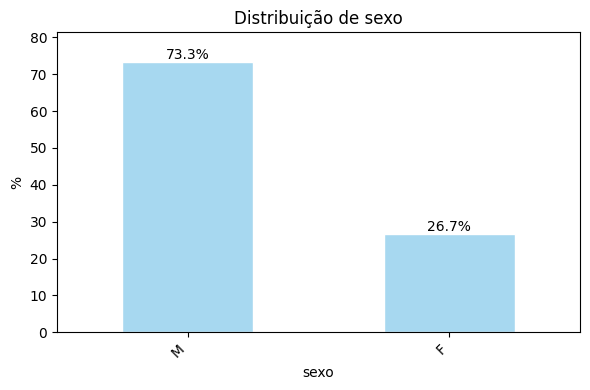

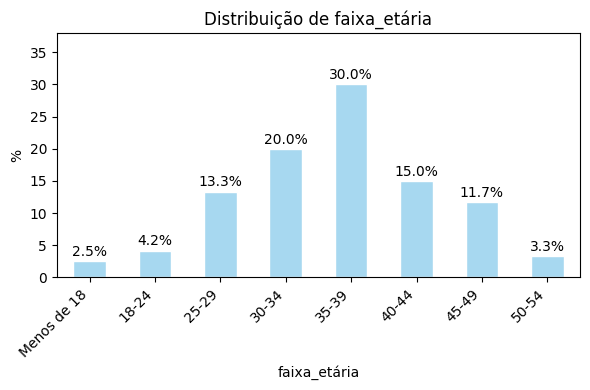

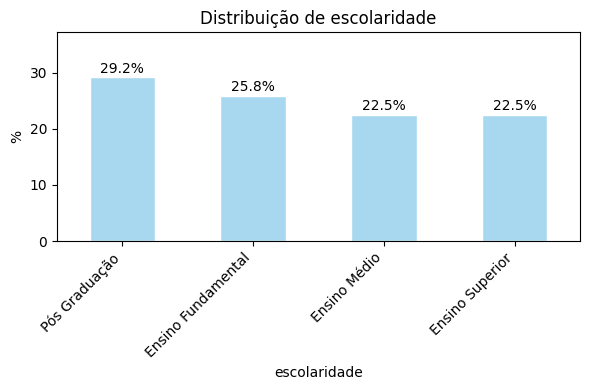

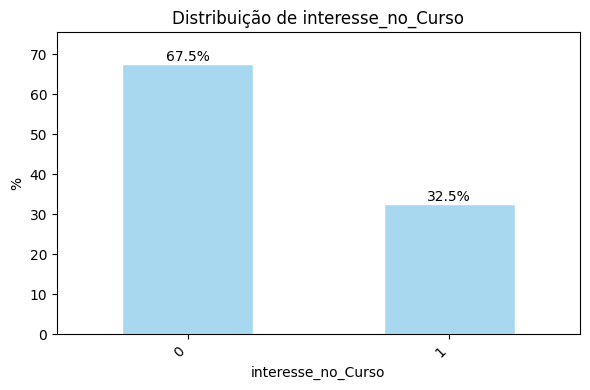

In [29]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

#dados de interesse:
quali = ['sexo','faixa_etária', 'escolaridade','interesse_no_Curso']

def eda_qualitativos (df,coluna):
  freq = df[coluna].value_counts()/len(df)*100

  if coluna == 'faixa_etária':
        ordem = [
            'Menos de 18',
            '18-24',
            '25-29',
            '30-34',
            '35-39',
            '40-44',
            '45-49',
            '50-54'
        ]
        freq = freq.reindex(ordem)

  return freq

# cria um PDF para armazenar TODOS os gráficos
with PdfPages('analise univariada - dados quali.pdf') as pdf:

    # loop para gerar um gráfico para cada variável
    for coluna in quali:

        # aplica função
        analise = eda_qualitativos(df_1, coluna)

        # cria figura
        plt.figure(figsize=(6,4))

        # gera gráfico de barras
        ax = analise.plot(
            kind='bar',
            color='#A7D8F0',      # azul bebê
            edgecolor='white'     # borda branca
        )

        # título do gráfico
        plt.title(f'Distribuição de {coluna}')

        # nome do eixo Y
        plt.ylabel('%')

        # aumenta o limite superior do eixo Y para não cortar os rótulos
        plt.ylim(0, analise.max() + 8)

        # adiciona rótulos em cima das barras
        for i, valor in enumerate(analise):

            plt.text(
                i,                # posição horizontal
                valor + 0.8,      # posição vertical
                f'{valor:.1f}%',  # texto exibido
                ha='center'       # alinhamento horizontal
            )

        # ajusta eixo X
        plt.xticks(rotation=45, ha='right')

        # ajusta automaticamente margens
        plt.tight_layout()

        # salva página no PDF
        pdf.savefig()

        # mostra gráfico no notebook
        plt.show()

        # fecha figura para evitar sobreposição/memória
        plt.close()



# EDA Univariada - Dados quantitativos

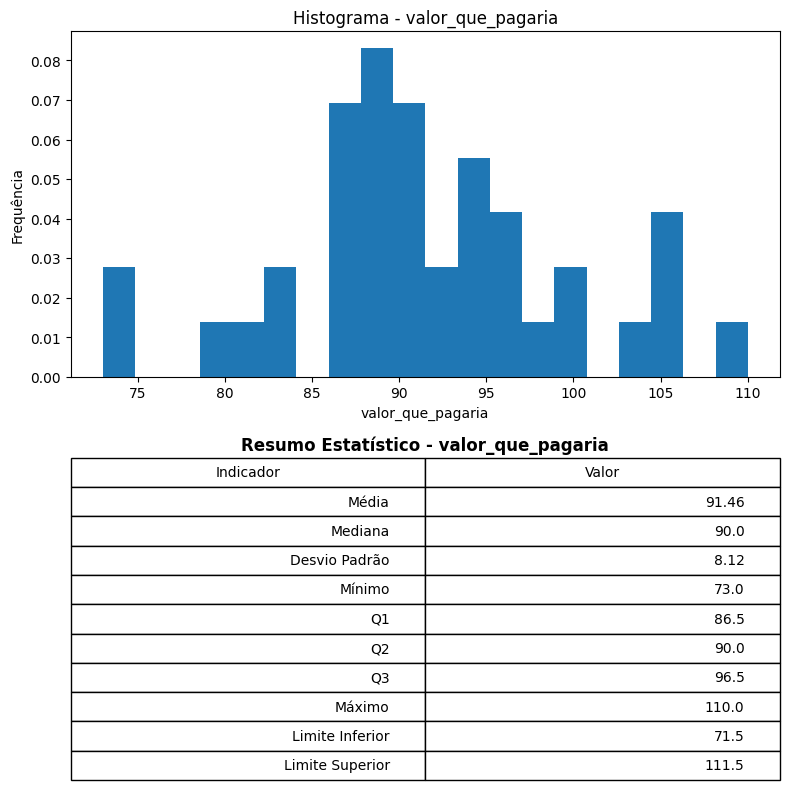

In [30]:

quanti = ['valor_que_pagaria']

def eda_quanti(df, coluna):

    media = df[coluna].mean()
    mediana = df[coluna].median()
    desvio = df[coluna].std()

    minimo = df[coluna].min()
    maximo = df[coluna].max()

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.5)
    q3 = df[coluna].quantile(0.75)

    # IQR
    iqr = q3 - q1

    # limites
    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    # dicionário com resultados
    resumo = {
        'Média': media,
        'Mediana': mediana,
        'Desvio Padrão': desvio,
        'Mínimo': minimo,
        'Q1': q1,
        'Q2': q2,
        'Q3': q3,
        'Máximo': maximo,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior
    }

    return resumo


# LOOP DAS VARIÁVEIS e CRIANDO PDF
with PdfPages('analise univariada - dados quanti.pdf') as pdf:

    for coluna in quanti:

      resumo = eda_quanti(df_2, coluna)

      # -------------------------
      # FIGURA
      # -------------------------

      fig, ax = plt.subplots(
          2, 1,
          figsize=(8,8),
          gridspec_kw={'height_ratios': [2,1.8]}
      )

      # -------------------------
      # HISTOGRAMA
      # -------------------------

      ax[0].hist(
          df_2[coluna].dropna(),
          bins=20,
          density = True
      )

      ax[0].set_title(f'Histograma - {coluna}')
      ax[0].set_xlabel(coluna)
      ax[0].set_ylabel('Frequência')

      # -------------------------
      # TABELA RESUMO
      # -------------------------

      tabela_resumo = pd.DataFrame(
          resumo.items(),
          columns=['Indicador', 'Valor']
      )

      # limita valores para 2 casas decimais
      tabela_resumo['Valor'] = tabela_resumo['Valor'].round(2)

      ax[1].axis('off')

      ax[1].set_title(
          f'Resumo Estatístico - {coluna}',
          fontsize=12,
          fontweight='bold',
          pad=10
      )

      tabela = ax[1].table(
          cellText=tabela_resumo.values,
          colLabels=tabela_resumo.columns,
          loc='center'
      )

      tabela.auto_set_font_size(False)
      tabela.set_fontsize(10)
      tabela.scale(1, 1.5)

      # ajusta layout
      plt.tight_layout()

      # salva página no PDF
      pdf.savefig()

      #mostrar figura
      plt.show()

      # fecha figura
      plt.close()



# EDA bivariada - Dados qualitativos

O objetivo do código abaixo é comparar cada variável qualitativa com a variável binária de interesse, **a fim de identificar se existe alguma diferença no comportamento da variável binária entre as categorias da variável qualitativa.**

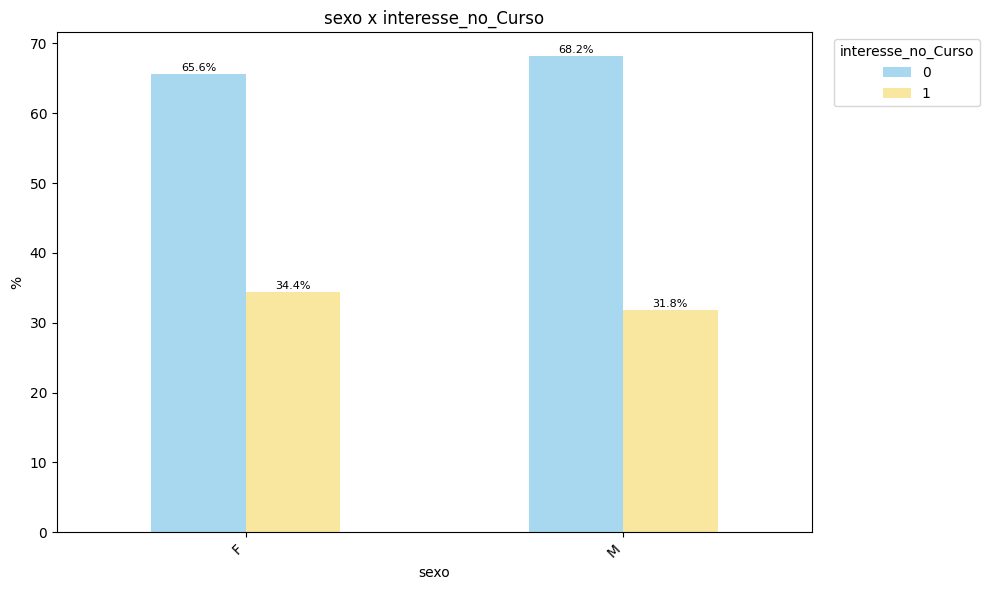


==== sexo ====

interesse_no_Curso      0      1
sexo                            
F                   65.62  34.38
M                   68.18  31.82


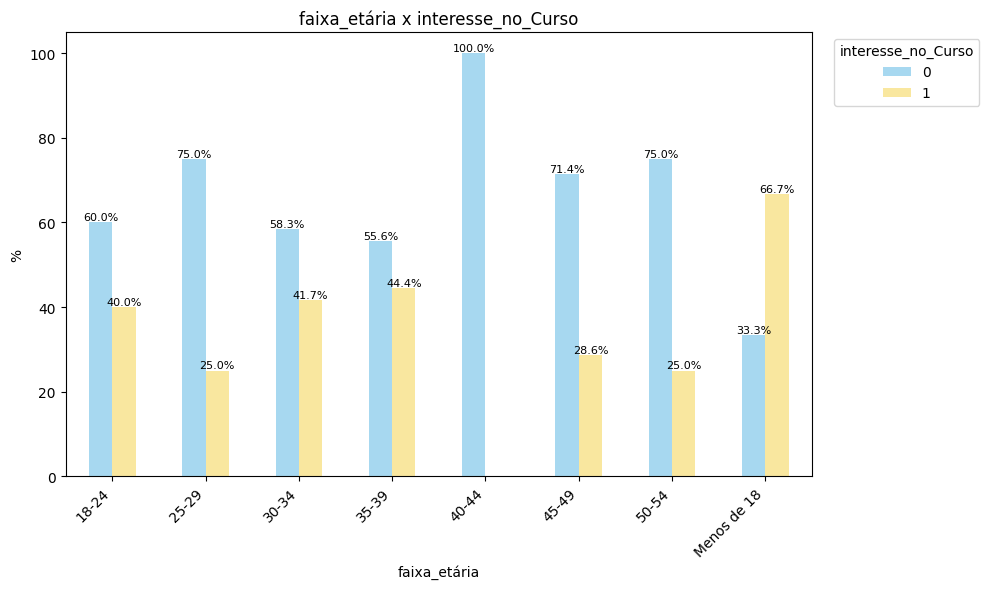


==== faixa_etária ====

interesse_no_Curso       0      1
faixa_etária                     
18-24                60.00  40.00
25-29                75.00  25.00
30-34                58.33  41.67
35-39                55.56  44.44
40-44               100.00   0.00
45-49                71.43  28.57
50-54                75.00  25.00
Menos de 18          33.33  66.67


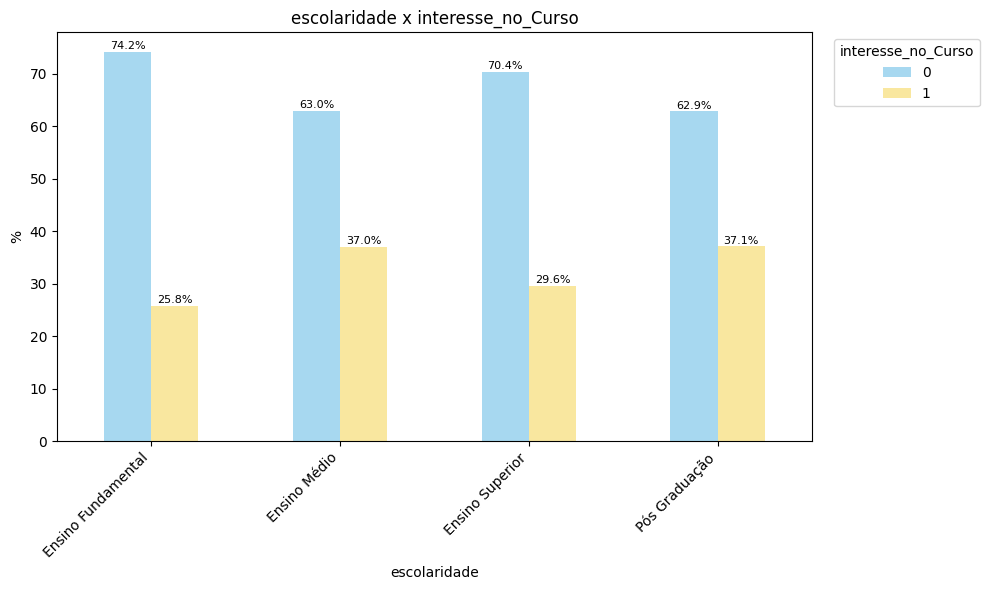


==== escolaridade ====

interesse_no_Curso      0      1
escolaridade                    
Ensino Fundamental  74.19  25.81
Ensino Médio        62.96  37.04
Ensino Superior     70.37  29.63
Pós Graduação       62.86  37.14


In [31]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

# coluna target binária
target = 'interesse_no_Curso'

# variáveis qualitativas para análise
quali = ['sexo', 'faixa_etária', 'escolaridade']

# cria PDF
with PdfPages('analise bivariada - dados quali.pdf') as pdf:

    for coluna in quali:

        # tabela percentual
        #Dentro de cada categoria da coluna em questão, qual é a porcentagem de
        #cada classe da variável alvo?
        tabela = pd.crosstab(
            df_1[coluna],
            df_1[target],
            normalize='index'
        ) * 100

        # cria gráfico
        ax = tabela.plot(
            kind='bar',
            figsize=(10,6),
            color=['#A7D8F0', '#F9E79F']
        )

        # título
        plt.title(f'{coluna} x {target}')

        # eixo Y
        plt.ylabel('%')

        # eixo X
        plt.xticks(rotation=45, ha='right')

        # legenda
        plt.legend(title=target,
        bbox_to_anchor=(1.02, 1),
        loc='upper left')

        # adiciona valores nas barras
        for p in ax.patches:

            altura = p.get_height()

            if altura > 0:

                ax.text(
                    p.get_x() + p.get_width()/2,
                    altura + 0.5,
                    f'{altura:.1f}%',
                    ha='center',
                    fontsize=8
                )

        # ajusta layout
        plt.tight_layout()

        # salva PDF
        pdf.savefig()

        # mostra gráfico
        plt.show()

        # fecha figura
        plt.close()

        # imprime tabela
        print(f'\n==== {coluna} ====\n')
        print(round(tabela,2))


Cálculo do information value para faixa etaria e escolaridade, vs interesse_no_curso

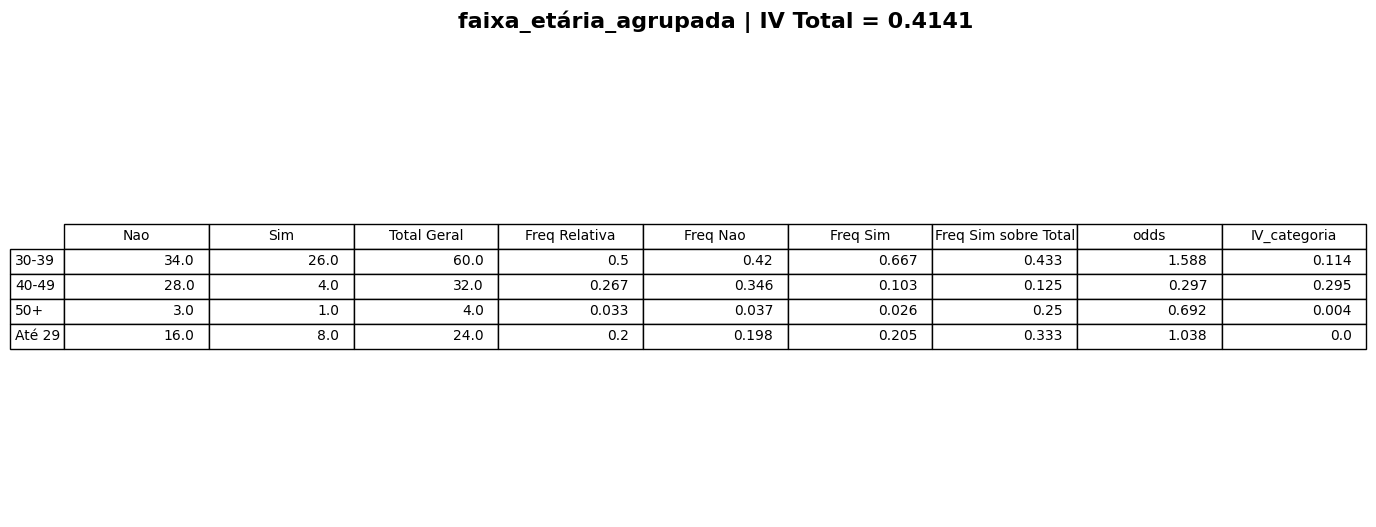

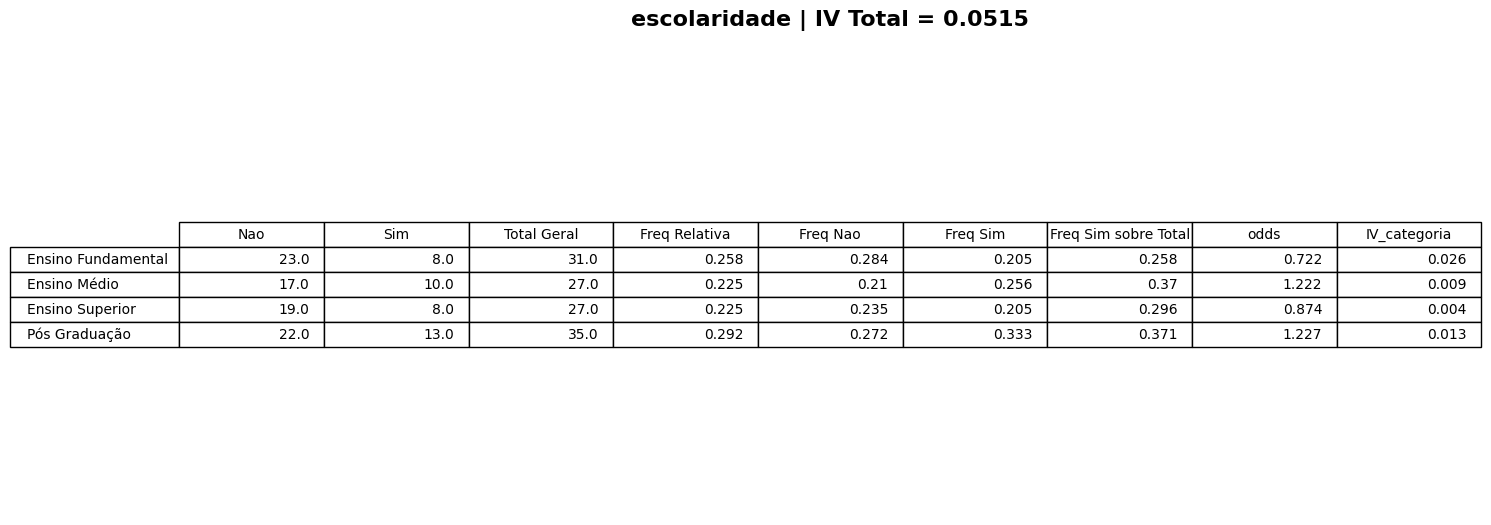

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

#A categoria 40–44 anos não apresentou nenhum respondente interessado no curso,
#fazendo com que o cálculo do Information Value resultasse em um valor infinito.
#por isso, vamos reagrupar as faixas etárias

# Agrupar faixas etárias
mapa_faixa = {
    'Menos de 18': 'Até 29',
    '18-24': 'Até 29',
    '25-29': 'Até 29',

    '30-34': '30-39',
    '35-39': '30-39',

    '40-44': '40-49',
    '45-49': '40-49',

    '50-54': '50+'
}


df_1['faixa_etária_agrupada'] = df_1['faixa_etária'].map(mapa_faixa)

target = 'interesse_no_Curso'

quali = [
    'faixa_etária_agrupada',
    'escolaridade'
]

# criar pdf
with PdfPages('iv.pdf') as pdf:

    for coluna in quali:

        # tabela
        tabela = pd.crosstab(
            df_1[coluna],
            df_1[target]
        )

        tabela.columns = ['Nao', 'Sim']

        tabela['Total Geral'] = tabela['Nao'] + tabela['Sim']

        tabela['Freq Relativa'] = (
            tabela['Total Geral'] /
            tabela['Total Geral'].sum()
        )

        tabela['Freq Nao'] = (
            tabela['Nao'] /
            tabela['Nao'].sum()
        )

        tabela['Freq Sim'] = (
            tabela['Sim'] /
            tabela['Sim'].sum()
        )

        tabela['Freq Sim sobre Total'] = (
            tabela['Sim'] /
            tabela['Total Geral']
        )

        tabela['odds'] = (
            tabela['Freq Sim'] /
            tabela['Freq Nao']
        )

        tabela['IV_categoria'] = (
            (tabela['Freq Sim'] - tabela['Freq Nao']) *
            np.log(tabela['odds'])
        )

        iv_total = tabela['IV_categoria'].sum()

        # arredondar
        tabela = tabela.round(3)

        # criar figura
        fig, ax = plt.subplots(figsize=(14, 6))

        ax.axis('off')

        # título
        ax.set_title(
            f'{coluna} | IV Total = {iv_total:.4f}',
            fontsize=16,
            fontweight='bold',
            pad=20
        )

        # tabela visual
        tabela_plot = ax.table(
            cellText=tabela.values,
            colLabels=tabela.columns,
            rowLabels=tabela.index,
            loc='center'
        )

        tabela_plot.auto_set_font_size(False)
        tabela_plot.set_fontsize(10)
        tabela_plot.scale(1.2, 1.5)

        # salvar página
        pdf.savefig(fig, bbox_inches='tight')

        # mostra
        plt.show()

        plt.close()



# **# Inferência estatística:**

Intervalo de confiança para proporção populacional

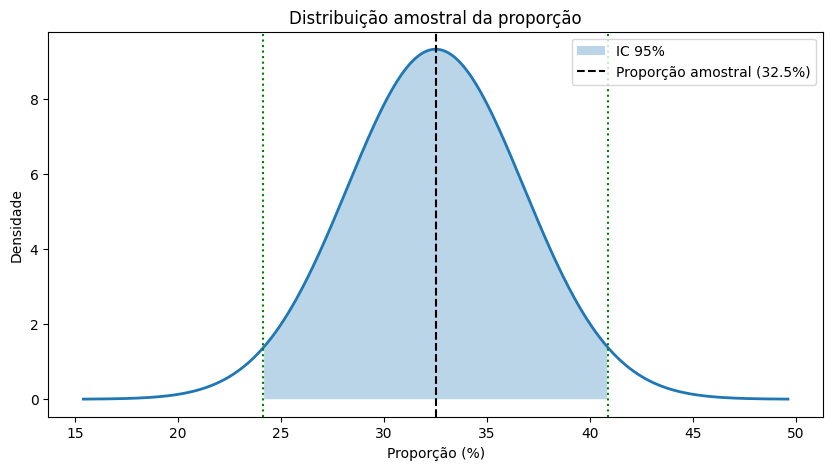

IC de 95%:24.12%, 40.88%


In [33]:
import scipy.stats as st

#calcular proporção de interessados na amostra
interessados = df['interesse_no_Curso'][df['interesse_no_Curso']==1].sum()
total = df['interesse_no_Curso'].count()
p_hat = interessados/total

def intervalo_de_confianca_proporcao(p_hat, n, confianca, grafico=False):

    # alpha representa a probabilidade total fora do intervalo
    alpha = (1 - confianca) / 2

    # Valor crítico da Normal
    z_alpha = abs(st.norm.ppf(alpha))

    # Erro padrão da proporção
    erro_padrao = np.sqrt(p_hat * (1 - p_hat) / n)

    # Intervalo de confiança
    IC1 = p_hat - z_alpha * erro_padrao
    IC2 = p_hat + z_alpha * erro_padrao

    if grafico:

        x = np.linspace(
            p_hat - 4 * erro_padrao,
            p_hat + 4 * erro_padrao,
            500
        )

        y = st.norm.pdf(x, loc=p_hat, scale=erro_padrao)

        plt.figure(figsize=(10,5))

        # Curva da distribuição amostral
        plt.plot(x*100, y, linewidth=2)

        # Área do IC
        x_fill = x[(x >= IC1) & (x <= IC2)]
        y_fill = st.norm.pdf(x_fill, loc=p_hat, scale=erro_padrao)

        plt.fill_between(x_fill*100, y_fill, alpha=0.3, label='IC 95%')

        # Estimativa pontual
        plt.axvline(
            p_hat*100,
            color='black',
            linestyle='--',
            label=f'Proporção amostral ({p_hat*100:.1f}%)'
        )

        # Limites do IC
        plt.axvline(IC1*100, color='green', linestyle=':')
        plt.axvline(IC2*100, color='green', linestyle=':')

        plt.title('Distribuição amostral da proporção')
        plt.xlabel('Proporção (%)')
        plt.ylabel('Densidade')
        plt.legend()
        plt.show()

    return IC1, IC2

IC = intervalo_de_confianca_proporcao(
    p_hat,
    total,
    0.95,
    grafico=True
)


li, ls = IC
print(f'IC de 95%:{li*100:.2f}%, {ls*100:.2f}%')

Teste de hipóteses para proporção populacional

Estatística Z = 1.897
p-valor = 0.02889
Proporção observada = 0.325 (32.5%)
Valor crítico = 0.315
Decisão: Rejeitar H0


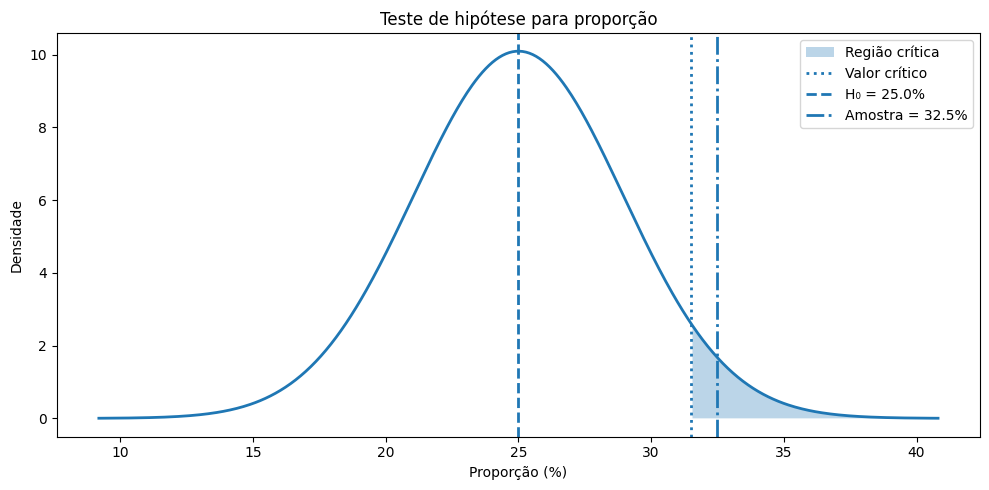

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

def teste_hipotese_proporcao(
    p0,
    p_hat,
    n,
    significancia=0.05,
    tipo_teste='direita',   # 'direita', 'esquerda' ou 'bilateral'
    grafico=False
):


    # Erro padrão sob H0
    erro_padrao = np.sqrt(p0 * (1 - p0) / n)

    # Estatística do teste
    z_obs = (p_hat - p0) / erro_padrao

    if tipo_teste == 'direita':

        z_critico = st.norm.ppf(1-significancia)
        p_valor = 1 - st.norm.cdf(z_obs)

        rejeita = z_obs > z_critico

        regiao = p0 + z_critico*erro_padrao

    elif tipo_teste == 'esquerda':

        z_critico = st.norm.ppf(significancia)
        p_valor = st.norm.cdf(z_obs)

        rejeita = z_obs < z_critico

        regiao = p0 + z_critico*erro_padrao

    elif tipo_teste == 'bilateral':

        z_critico = st.norm.ppf(1-significancia/2)
        p_valor = 2*(1-st.norm.cdf(abs(z_obs)))

        rejeita = abs(z_obs) > z_critico

        regiao = (
            p0-z_critico*erro_padrao,
            p0+z_critico*erro_padrao
        )

    else:
        raise ValueError(
            "tipo_teste deve ser 'direita', 'esquerda' ou 'bilateral'."
        )

    # Resultados

    print(f'Estatística Z = {z_obs:.3f}')
    print(f'p-valor = {p_valor:.5f}')

    print(f'Proporção observada = {p_hat:.3f} ({p_hat*100:.1f}%)')

    if tipo_teste == 'bilateral':
        print(f'Valores críticos = ({regiao[0]:.3f}, {regiao[1]:.3f})')
    else:
        print(f'Valor crítico = {regiao:.3f}')

    if rejeita:
        print('Decisão: Rejeitar H0')
    else:
        print('Decisão: Não rejeitar H0')

    # Gráfico

    if grafico:

        x = np.linspace(
            p0-4*erro_padrao,
            p0+4*erro_padrao,
            500
        )

        y = st.norm.pdf(x, loc=p0, scale=erro_padrao)

        plt.figure(figsize=(10,5))

        plt.plot(x*100, y, linewidth=2)

        # Região crítica

        if tipo_teste == 'direita':

            x_fill = x[x >= regiao]
            y_fill = st.norm.pdf(x_fill, loc=p0, scale=erro_padrao)

            plt.fill_between(
                x_fill*100,
                y_fill,
                alpha=0.3,
                label='Região crítica'
            )

            plt.axvline(regiao*100,
                        linestyle=':',
                        linewidth=2,
                        label='Valor crítico')

        elif tipo_teste == 'esquerda':

            x_fill = x[x <= regiao]
            y_fill = st.norm.pdf(x_fill, loc=p0, scale=erro_padrao)

            plt.fill_between(
                x_fill*100,
                y_fill,
                alpha=0.3,
                label='Região crítica'
            )

            plt.axvline(regiao*100,
                        linestyle=':',
                        linewidth=2,
                        label='Valor crítico')

        else:

            li, ls = regiao

            x_fill1 = x[x <= li]
            y_fill1 = st.norm.pdf(x_fill1, loc=p0, scale=erro_padrao)

            x_fill2 = x[x >= ls]
            y_fill2 = st.norm.pdf(x_fill2, loc=p0, scale=erro_padrao)

            plt.fill_between(x_fill1*100, y_fill1, alpha=0.3)
            plt.fill_between(x_fill2*100, y_fill2, alpha=0.3)

            plt.axvline(li*100, linestyle=':', linewidth=2)
            plt.axvline(ls*100, linestyle=':', linewidth=2)

        # H0

        plt.axvline(
            p0*100,
            linestyle='--',
            linewidth=2,
            label=f'H₀ = {p0*100:.1f}%'
        )

        # Amostra

        plt.axvline(
            p_hat*100,
            linestyle='-.',
            linewidth=2,
            label=f'Amostra = {p_hat*100:.1f}%'
        )

        plt.title('Teste de hipótese para proporção')
        plt.xlabel('Proporção (%)')
        plt.ylabel('Densidade')
        plt.legend()

        plt.tight_layout()
        plt.show()

    return {
        "z": z_obs,
        "p_valor": p_valor,
        "rejeita_h0": rejeita
    }

resultado = teste_hipotese_proporcao(
    p0=0.25,
    p_hat=p_hat,
    n=total,
    significancia=0.05,
    tipo_teste='direita',   # H1: p > 0.25
    grafico=True            # False se não quiser o gráfico
)

Intervalo de confiança para o preço médio

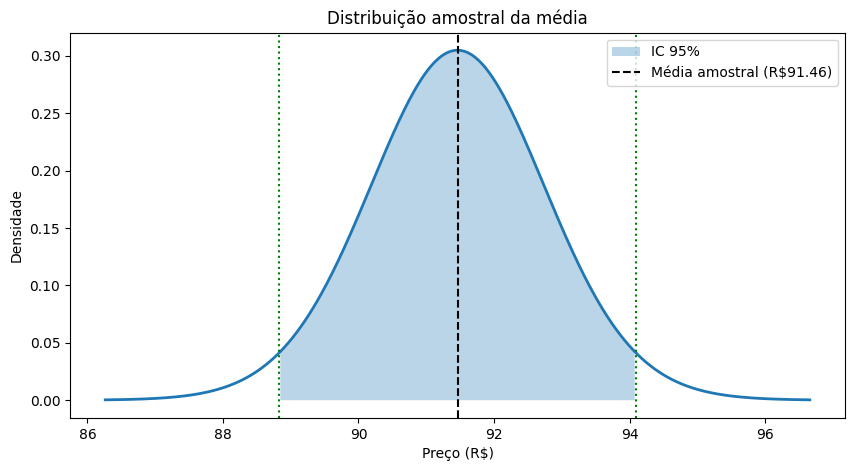

IC de 95%:88.83, 94.09


In [35]:
import scipy.stats

def intervalo_de_confianca_conj_dados(X, confianca, sigma=-1, grafico=False):

    X = np.array(X)

    # calcular o desvio padrão amostral
    def S(X):
        s = 0
        for i in range(len(X)):
            s += (X[i] - np.mean(X))**2
        s = np.sqrt(s/(len(X)-1))
        return s

    Xs = np.mean(X)
    n = len(X)
    s = S(X)

    # alpha representa a probabilidade (área) em cada cauda
    alpha = (1-confianca)/2

    # Valor crítico da Normal
    z_alpha = abs(scipy.stats.norm.ppf(alpha))

    # Desvio padrão conhecido
    if sigma != -1:

        erro_padrao = sigma / np.sqrt(n)

        IC1 = Xs - z_alpha * erro_padrao
        IC2 = Xs + z_alpha * erro_padrao

        distribuicao = scipy.stats.norm

    # Desvio padrão desconhecido
    else:

        erro_padrao = s / np.sqrt(n)

        if n >= 50:

            IC1 = Xs - z_alpha * erro_padrao
            IC2 = Xs + z_alpha * erro_padrao

            distribuicao = scipy.stats.norm

        else:

            t_alpha = abs(scipy.stats.t.ppf(alpha, n-1))

            IC1 = Xs - t_alpha * erro_padrao
            IC2 = Xs + t_alpha * erro_padrao

            distribuicao = scipy.stats.t

    if grafico:

        x = np.linspace(
            Xs - 4 * erro_padrao,
            Xs + 4 * erro_padrao,
            500
        )

        if distribuicao == scipy.stats.norm:
            y = distribuicao.pdf(x, loc=Xs, scale=erro_padrao)
        else:
            y = distribuicao.pdf((x - Xs)/erro_padrao, df=n-1) / erro_padrao

        plt.figure(figsize=(10,5))

        # Curva da distribuição
        plt.plot(x, y, linewidth=2)

        # Área do IC
        x_fill = x[(x >= IC1) & (x <= IC2)]

        if distribuicao == scipy.stats.norm:
            y_fill = distribuicao.pdf(x_fill, loc=Xs, scale=erro_padrao)
        else:
            y_fill = distribuicao.pdf((x_fill - Xs)/erro_padrao, df=n-1) / erro_padrao

        plt.fill_between(x_fill, y_fill, alpha=0.3, label='IC 95%')

        # Média amostral
        plt.axvline(
            Xs,
            color='black',
            linestyle='--',
            label=f'Média amostral (R${Xs:.2f})'
        )

        # Limites do IC
        plt.axvline(IC1, color='green', linestyle=':')
        plt.axvline(IC2, color='green', linestyle=':')


        plt.title('Distribuição amostral da média')
        plt.xlabel('Preço (R$)')
        plt.ylabel('Densidade')
        plt.legend()

        plt.show()

    return IC1, IC2

IC = intervalo_de_confianca_conj_dados(
    df_2['valor_que_pagaria'],
    0.95,
    grafico=True
)

li, ls = IC
print(f'IC de 95%:{li:.2f}, {ls:.2f}')